# First-Shot Concession Analysis: Ederson Moraes (2017–2025)

## Project Overview

This project investigates the dynamics of the **first shot on target faced by Manchester City** during matches in which Ederson was the starting goalkeeper. The goal of the analysis is to understand how often the first shot results in a goal, what contextual factors influence this outcome, and whether these goals occur more frequently than expected based on shot quality.

The analysis combines **event-level football data, expected goals (xG) metrics, exploratory data analysis, and a simple machine learning model** to examine first-shot concession risk across multiple Premier League seasons.

---

## Dataset

The dataset consists of **shot-level event data collected across eight seasons (2017–18 through 2024–25)** using a custom Python web scraper and the `soccerdata` library.

After preprocessing:

- **6,800+ shot events** were analyzed
- **245 matches** contained at least one shot on target faced by Ederson
- Each match contributes the **first shot faced as the primary analytical observation**

Key features include:

- shot minute
- opponent team
- expected goals (xG)
- match season
- total shots faced in the match

---

## Key Questions

This analysis focuses on three primary questions:

1. **How often does the first shot faced result in a goal?**
2. **Does shot quality (xG) explain these goals?**
3. **Do first-shot outcomes align with statistical expectations?**

---

## Key Findings

- The first shot on target results in a goal in roughly **25–40% of matches** across seasons.
- Goals from first shots generally come from **higher-xG chances** than shots that are saved.
- Across all seasons analyzed, **actual goals conceded from first shots (78) substantially exceed expected goals (~41 xG)**.
- This suggests that the first shot in a match may represent a **high-leverage defensive moment** where outcomes occur more frequently than typical shot probabilities would predict.

---

## Methodology

The analysis pipeline follows a standard data science workflow:

1. **Data Collection**
   - Multi-season shot data collected using a custom web scraper.

2. **Data Processing**
   - Filtering shots faced while Ederson was on the pitch.
   - Identifying the first shot faced in each match.

3. **Exploratory Data Analysis**
   - Shot frequency and concession rates.
   - Shot quality (xG) distribution.

4. **Machine Learning Modeling**
   - Logistic regression used to estimate the probability that the first shot results in a goal.

5. **Performance Analysis**
   - Comparison of expected vs actual goals to evaluate outcomes relative to shot quality.

---

## Tools Used

- Python
- Pandas
- Matplotlib
- Scikit-learn
- Soccerdata
- Jupyter Notebook

## Table of Contents

1. [Environment Setup](#Environment-Setup)
2. [Data Collection](#Data-Collection)
3. [Data Loading](#Data-Loading)
4. [Dataset Overview](#Dataset-Overview)
5. [Dataset Validation](#Dataset-Validation)
6. [Filtering Opponent Shot Events](#Filtering-Opponent-Shot-Events)
7. [Opponent Shot Analysis](#Opponent-Shot-Analysis)
8. [Goalkeeper Workload Analysis](#Goalkeeper-Workload-Analysis)
9. [First-Shot Concession Analysis](#First-Shot-Concession-Analysis)
10. [Timing of Goals Conceded](#Timing-of-Goals-Conceded)
11. [Shot Quality Analysis (xG)](#Shot-Quality-Analysis-(xG))
12. [Feature Engineering for Machine Learning](#Feature-Engineering-for-Machine-Learning)
13. [Machine Learning Model](#Machine-Learning-Model)
14. [Model Interpretation](#Model-Interpretation)
15. [Multi-Season Dataset Construction](#Multi-Season-Dataset-Construction)
16. [Seasonal Trends](#Seasonal-Trends)
17. [Expected vs Actual First-Shot Goals](#Expected-vs-Actual-First-Shot-Goals)
18. [Goalkeeper Over/Under Performance](#Goalkeeper-Over/Under-Performance)
19. [Key Findings](#Key-Findings)
20. [Future Work](#Future-Work)

## Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
import seaborn as sns
from pathlib import Path


In [3]:
# Manchester City themed plotting style
CITY_BLUE = "#6CABDD"
CITY_DARK = "#1C2C5B"

plt.style.use("default")

import matplotlib as mpl
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linestyle": "-",
    "grid.alpha": 0.6,
    "font.size": 11,
})

## Data Loading

In [4]:
DATA_PATH = Path("../data/raw/2017-18_ederson_shots.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,league,season,game,team,player,league_id,season_id,game_id,date,shot_id,...,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result,ederson_minutes
0,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Davy Pröpper,1,2017,7126,2017-08-12 17:30:00,158178,...,NaN,NaN,0.015211,0.775,0.561,55,Right Foot,From Corner,Missed Shot,90
1,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Davy Pröpper,1,2017,7126,2017-08-12 17:30:00,158182,...,NaN,NaN,0.022634,0.755,0.408,56,Right Foot,From Corner,Missed Shot,90
2,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158173,...,175828.0,Pascal Groß,0.034634,0.907,0.557,44,NaN,Set Piece,Saved Shot,90
3,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158180,...,NaN,NaN,0.087967,0.885,0.472,55,Right Foot,From Corner,Saved Shot,90
4,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158181,...,NaN,NaN,0.095741,0.883,0.522,55,Left Foot,From Corner,Blocked Shot,90


In [5]:
df.shape

(856, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   league            856 non-null    object 
 1   season            856 non-null    int64  
 2   game              856 non-null    object 
 3   team              856 non-null    object 
 4   player            856 non-null    object 
 5   league_id         856 non-null    int64  
 6   season_id         856 non-null    int64  
 7   game_id           856 non-null    int64  
 8   date              856 non-null    object 
 9   shot_id           856 non-null    int64  
 10  team_id           856 non-null    int64  
 11  player_id         856 non-null    int64  
 12  assist_player_id  625 non-null    float64
 13  assist_player     625 non-null    object 
 14  xg                856 non-null    float64
 15  location_x        856 non-null    float64
 16  location_y        856 non-null    float64
 1

In [7]:
df.describe()

,season,league_id,season_id,game_id,shot_id,team_id,player_id,assist_player_id,xg,location_x,location_y,minute,ederson_minutes
count,856.0,856.0,856.0,856.000000,856.000000,856.000000,856.000000,625.000000,856.000000,856.000000,856.000000,856.000000,856.000000
mean,1718.0,1.0,2017.0,7297.816589,180202.341121,89.127336,1267.670561,200716.148800,0.133330,0.847277,0.503645,47.050234,88.948598
std,0.0,0.0,0.0,106.104496,19098.041635,18.386593,1597.969422,21267.919446,0.183238,0.098916,0.125294,26.439357,6.801594
min,1718.0,1.0,2017.0,7126.000000,158166.000000,72.000000,200.000000,175822.000000,0.000000,0.027000,0.046000,0.000000,45.000000
25%,1718.0,1.0,2017.0,7202.000000,160171.750000,88.000000,525.500000,178439.000000,0.027550,0.786000,0.422000,24.000000,90.000000
50%,1718.0,1.0,2017.0,7298.000000,184215.500000,88.000000,618.000000,205408.000000,0.060417,0.866500,0.500000,46.000000,90.000000
75%,1718.0,1.0,2017.0,7382.000000,194223.250000,88.000000,813.000000,215526.000000,0.110486,0.916000,0.591000,69.000000,90.000000
max,1718.0,1.0,2017.0,7480.000000,213632.000000,220.000000,6525.000000,237926.000000,0.961314,0.983000,0.915000,100.000000,90.000000


## Dataset Overview

**Rows:** 856
**Columns:** 22

**Unit of observation:**
Each row represents a shot event in a Manchester City match where Ederson was present.

**Key observations:**

- The dataset contains 36 unique matches.
- Numeric columns include: season, season_id, league_id, game_id, shot_id, team_id, player_id, assist_player_id, xg, location_x, location_y, minute, ederson_minutes.
- Categorical columns include: league, game, team, player, date, assist_player, body_part, situation, result.
- Missing values are minimal and appear primarily in the assist_player_id column.

**Initial assessment:**
The dataset appears structurally consistent for event-level analysis, though further validation of shot ordering is required.

## Dataset Validation

In [8]:
df.groupby('game_id').size().describe()

count    36.000000
mean     23.777778
std       4.799471
min      14.000000
25%      20.750000
50%      24.000000
75%      27.000000
max      35.000000
dtype: float64

## Match-Level Shot Distribution

**Findings:**

- Average shots per match: 23.778
- Minimum shots in a match: 14
- Maximum shots in a match: 35

**Interpretation:**

Shot volume varies between matches, which is expected in Premier League play.
No immediate structural anomalies were detected.

In [9]:
df['ederson_minutes'].describe()

count    856.000000
mean      88.948598
std        6.801594
min       45.000000
25%       90.000000
50%       90.000000
75%       90.000000
max       90.000000
Name: ederson_minutes, dtype: float64

In [10]:
print(f"The number of games Ederson did not complete a full 90 Minutes: {(df.groupby('game_id')['ederson_minutes'].max() < 90).sum()}")

The number of games Ederson did not complete a full 90 Minutes: 1


In [11]:
df.groupby('game_id')['ederson_minutes'].value_counts().sort_index()

game_id  ederson_minutes
7126     90                 21
7138     90                 26
7139     90                 28
7149     45                 20
7164     90                 35
7173     90                 30
7185     90                 21
7194     90                 26
7202     90                 21
7215     90                 21
7228     90                 15
7235     90                 14
7245     90                 19
7257     90                 32
7262     90                 31
7276     90                 22
7281     90                 30
7298     90                 27
7308     90                 19
7315     90                 27
7321     90                 25
7335     90                 25
7343     90                 27
7354     90                 27
7366     90                 22
7372     90                 28
7382     90                 21
7389     90                 19
7404     90                 16
7416     90                 20
7433     90                 24
7445     90   

## Ederson Minutes Validation

**Findings:**

- Minimum minutes: 45
- Maximum minutes: 90
- Matches with <90 minutes: 1
- Missing values: 0

**Interpretation:**

The minutes data appears consistent with expectations for a starting goalkeeper. Ederson missed the second half of the game against Liverpool at The Etihad Stadium due to injury.
Incomplete matches will be excluded from full-match concession analysis.

In [12]:
df['result'].value_counts()


result
Missed Shot     307
Saved Shot      209
Blocked Shot    197
Goal            123
Shot On Post     15
Own Goal          5
Name: count, dtype: int64

## Shot Result Distribution

**Observed result types:**


- Missed Shot
- Saved Shot
- Blocked Shot
- Goal
- Shot on Post
- Own Goal

**Interpretation:**

The dataset does contain off-target shot events.
For first-shot analysis, only on-target events will be considered in the match timeline.

In [13]:
sample_game_id = df['game_id'].iloc[0]

sample_game = (
    df[df['game_id'] == sample_game_id]
    .sort_values('minute')
)

sample_game[['minute', 'result', 'team']].head(10)

,minute,result,team
10,3,Blocked Shot,Manchester City
7,8,Missed Shot,Manchester City
8,13,Missed Shot,Manchester City
14,16,Saved Shot,Manchester City
15,31,Blocked Shot,Manchester City
12,33,Shot On Post,Manchester City
11,33,Saved Shot,Manchester City
2,44,Saved Shot,Brighton
13,44,Missed Shot,Manchester City
18,47,Blocked Shot,Manchester City


In [14]:
sample_game['minute'].is_monotonic_increasing

True

## Shot Ordering Validation

**Findings:**

- Shot events appear ordered by minute: True
- First event in sample match: Blocked Shot
- Ordering consistency: True

**Interpretation:**

The event timeline appears reliable.
Match timelines will be explicitly sorted by minute during metric computation.

## Filtering Opponent Shot Events

In [15]:
all_shots_mask = (
        (
            ((df['team'] != 'Manchester City') & (df['result'] != 'Own Goal'))|
            ((df['team'] == 'Manchester City') & (df['result'] == 'Own Goal'))
        )&
        (
            (df['minute'] <= df['ederson_minutes']) |
            ((df['ederson_minutes'] == 90) & (df['minute'] >= 90 ))
        )
)

In [16]:
# Validation: Proving the Mask correctly identifies Own Goals & Minute Constraints
df_block_a = df[all_shots_mask].copy()

# 2. Validation Table: Checking the 4 Logic Gates
# We pick specific indices from the CSV that represent our edge cases
test_indices = [2, 192, 5, 54]
# 2: Opponent Shot, 192: City OG, 5: Opponent OG, 54: Stoppage Time (95')

validation_check = df.loc[test_indices].copy()
validation_check['Passed_Mask'] = validation_check.index.isin(df_block_a.index)

# Add a 'Scenario' column for clarity in the portfolio
scenarios = {
    2: "Standard Opponent Shot",
    192: "Man City Own Goal",
    5: "Opponent Own Goal (Exclude)",
    54: "Stoppage Time (95 min)"
}
validation_check['Scenario'] = validation_check.index.map(scenarios)

print("--- BLOCK A: MASK VALIDATION ---")
display(validation_check[['Scenario', 'team', 'result', 'minute', 'ederson_minutes', 'Passed_Mask']])

--- BLOCK A: MASK VALIDATION ---


,Scenario,team,result,minute,ederson_minutes,Passed_Mask
2,Standard Opponent Shot,Brighton,Saved Shot,44,90,True
192,Man City Own Goal,Manchester City,Own Goal,46,90,True
5,Opponent Own Goal (Exclude),Brighton,Own Goal,74,90,False
54,Stoppage Time (95 min),Bournemouth,Saved Shot,95,90,True


In [17]:
opp_shots_per_match = (
    df_block_a
    .groupby('game_id')
    .size()
)

print(opp_shots_per_match.describe())

count    36.000000
mean      6.166667
std       2.591194
min       2.000000
25%       5.000000
50%       6.000000
75%       7.000000
max      16.000000
dtype: float64


## Opponent Shot Analysis

This section evaluates total opponent shooting activity while Ederson was on the pitch, providing defensive context for subsequent goalkeeper analysis.

**Summary Statistics:**

- Matches analyzed: 36
- Average opponent shots: 6.17 shots
- Minimum opponent shots: 2 shots
- Maximum opponent shots: 16 shots

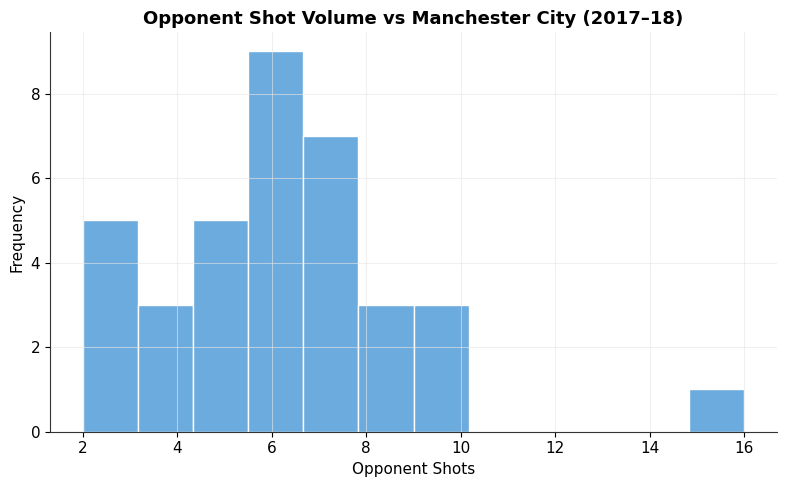

In [18]:
plt.figure(figsize=(8,5))
plt.hist(
    opp_shots_per_match,
    bins=12,
    color=CITY_BLUE,
    edgecolor="white"
)
plt.tight_layout()

plt.title(
    "Opponent Shot Volume vs Manchester City (2017–18)",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Opponent Shots")
plt.ylabel("Frequency")
sns.despine()
plt.tight_layout()
plt.show()

**Distribution Insight:**

Opponent shot volume appears right-skewed.

Most matches fall within 5-8 opponent shots.

**Interpretation:**

This establishes the defensive pressure environment Manchester City faced during the season.

In [19]:
print(df_block_a['result'].value_counts(normalize=True))

result
Missed Shot     0.382883
Saved Shot      0.252252
Blocked Shot    0.234234
Goal            0.108108
Shot On Post    0.013514
Own Goal        0.009009
Name: proportion, dtype: float64


## Opponent Shot Outcome Distribution

**Outcome Breakdown (%):**

- Saved Shots: 25.23%
- Blocked Shots: 23.42%
- Goals: 10.81%
- Shots Hit Woodwork: 1.35%
- Own Goals: 0.90%
- Missed Shots: 38.29%

**Interpretation:**

The majority of opponent attempts failed to reach the target (missed or blocked), suggesting that Manchester City’s defensive structure effectively suppressed shot quality.

## Goalkeeper Workload Analysis

In [20]:
shots_faced_mask = (
    (
        (df['team'] != 'Manchester City') &
        (df['result'].isin(['Saved Shot', 'Goal']))
    ) |
    (
        (df['team'] == 'Manchester City') &
        (df['result'] == 'Own Goal')
    )
) & (
    df['minute'].notna() &
    df['ederson_minutes'].notna() &
    (df['minute'] <= df['ederson_minutes'])
)

df_faced = df[shots_faced_mask].copy()

In [21]:
df_faced['result'].value_counts()

result
Saved Shot    51
Goal          22
Own Goal       2
Name: count, dtype: int64

In [22]:
shots_faced_per_match = (
    df_faced
    .groupby('game_id')
    .size()
)

shots_faced_per_match.describe()

count    29.000000
mean      2.586207
std       1.500410
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       7.000000
dtype: float64

In [23]:
total_matches = df['game_id'].nunique()
matches_with_shots = shots_faced_per_match.count()
zero_shot_matches = total_matches - matches_with_shots

total_matches, matches_with_shots, zero_shot_matches

(36, np.int64(29), np.int64(7))

**Zero-Shot Matches**

A subset of matches featured no shots on target against Manchester City while Ederson was on the pitch. These matches are analytically important because they reduce exposure volume and increase the leverage of the first shot faced in matches where shots do occur.

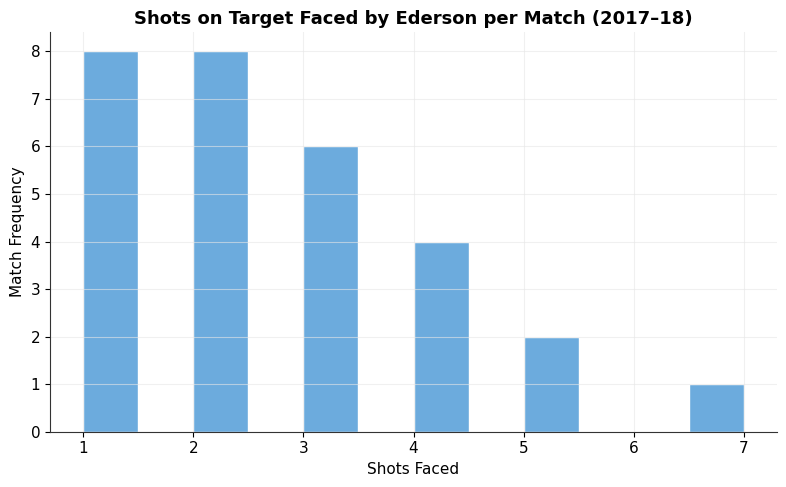

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    shots_faced_per_match,
    bins=12,
    color=CITY_BLUE,
    edgecolor="white"
)

plt.title(
    "Shots on Target Faced by Ederson per Match (2017–18)",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Shots Faced")
plt.ylabel("Match Frequency")
sns.despine()
plt.tight_layout()
plt.show()

## Shots on Target Faced by Ederson

This section isolates goalkeeper-relevant events (opponent shots on target and own goals) that occurred while Ederson was on the pitch.

**Summary Statistics:**

- Total matches analyzed: **36**
- Matches with ≥1 shot on target faced: **29**
- Matches with zero shots on target faced: **7**
- Average shots faced (conditional on ≥1): **2.59 shots**
- Minimum shots faced: **1 shot**
- Maximum shots faced: **7 shots**

**Distribution Insight:**

The distribution of shots on target faced per match is moderately right-skewed, with most matches falling between **1–3 shots faced**.

**Interpretation:**

Ederson typically faced a low on-target workload per match, reflecting Manchester City’s strong territorial control during the 2017–18 Premier League season. Notably, several matches featured **zero shots on target faced**, highlighting the team’s defensive dominance and the relatively low exposure environment for the goalkeeper.

In [25]:
df_faced['result'].value_counts(normalize=True)

result
Saved Shot    0.680000
Goal          0.293333
Own Goal      0.026667
Name: proportion, dtype: float64

### Shot Outcome Distribution (Faced Shots)

**Outcome Breakdown (%):**

- Saved Shots: **68.0%**
- Goals: **29.3%**
- Own Goals: **2.7%**

**Interpretation:**

Among shots on target faced while Ederson was on the pitch, approximately **68% were saved**, while roughly **29% resulted in goals**. This establishes the baseline concession environment prior to isolating first-shot events and provides context for evaluating goalkeeper performance under limited but high-leverage exposure.

Having established Ederson’s overall shot exposure and outcome profile, the next section isolates first-shot events at the match level.

In [26]:
df_faced_sorted = (
    df_faced
    .sort_values(['game_id', 'minute'])
)

In [27]:
first_shots = (
    df_faced_sorted
    .groupby('game_id')
    .first()
    .reset_index()
)

first_shots.head()

,game_id,league,season,game,team,player,league_id,season_id,date,shot_id,...,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result,ederson_minutes
0,7126,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,2017-08-12 17:30:00,158173,...,175828.0,Pascal Groß,0.034634,0.907,0.557,44,Right Foot,Set Piece,Saved Shot,90
1,7138,ENG-Premier League,1718,2017-08-21 Manchester City-Everton,Everton,Wayne Rooney,1,2017,2017-08-21 20:00:00,158522,...,176228.0,Dominic Calvert-Lewin,0.460745,0.916,0.452,34,Left Foot,Open Play,Goal,90
2,7139,ENG-Premier League,1718,2017-08-26 Bournemouth-Manchester City,Bournemouth,Charlie Daniels,1,2017,2017-08-26 12:30:00,159184,...,176901.0,Andrew Surman,0.017740,0.878,0.806,12,Left Foot,Open Play,Goal,90
3,7149,ENG-Premier League,1718,2017-09-09 Manchester City-Liverpool,Liverpool,Roberto Firmino,1,2017,2017-09-09 12:30:00,159382,...,177137.0,Jordan Henderson,0.067057,0.964,0.614,14,Right Foot,Open Play,Saved Shot,45
4,7164,ENG-Premier League,1718,2017-09-16 Watford-Manchester City,Watford,Nathaniel Chalobah,1,2017,2017-09-16 15:00:00,158951,...,176624.0,José Holebas,0.053284,0.878,0.493,52,Right Foot,From Corner,Saved Shot,90


In [28]:
first_shots['first_shot_conceded'] = (
    first_shots['result'] == 'Goal'
).astype(int)

first_shots[['game_id', 'result', 'first_shot_conceded']].head()

,game_id,result,first_shot_conceded
0,7126,Saved Shot,0
1,7138,Goal,1
2,7139,Goal,1
3,7149,Saved Shot,0
4,7164,Saved Shot,0


In [29]:
first_shot_rate = first_shots['first_shot_conceded'].mean()

print(f"First-shot concession rate: {first_shot_rate:.3f}")

First-shot concession rate: 0.310


In [30]:
total_first_shots = len(first_shots)
conceded_first_shots = first_shots['first_shot_conceded'].sum()

print(f"Matches with ≥1 shot faced: {total_first_shots}")
print(f"Matches where first shot was conceded: {conceded_first_shots}")

Matches with ≥1 shot faced: 29
Matches where first shot was conceded: 9


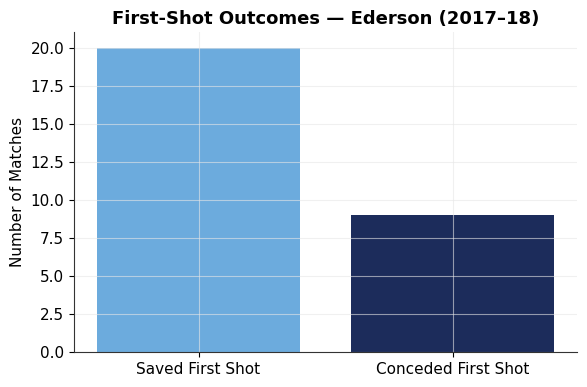

In [31]:
plt.figure(figsize=(6,4))

counts = first_shots['first_shot_conceded'].value_counts().sort_index()

plt.bar(
    ["Saved First Shot", "Conceded First Shot"],
    counts.values,
    color=[CITY_BLUE, CITY_DARK]
)

plt.title(
    "First-Shot Outcomes — Ederson (2017–18)",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Number of Matches")
sns.despine()
plt.tight_layout()
plt.show()

## First-Shot Concession Analysis

To evaluate early-match vulnerability, I isolated the first shot on target faced in each match and assessed whether it resulted in a goal.

**Results**

- Matches with ≥1 shot faced: **29**
- Matches where first shot resulted in a goal: **9**
- First-shot concession rate: **31.0%**

**Interpretation**

Ederson conceded on the first shot on target in approximately one-third of matches where he faced at least one shot. Given Manchester City’s generally low defensive exposure during the 2017–18 season, first-shot events represent high-leverage moments. This reinforces the importance of evaluating goalkeeper performance not only by aggregate save percentage but also by early-match resilience.

In [32]:
# Matches where Ederson conceded at least one goal
matches_with_goal = (
    df_faced[df_faced['result'] == 'Goal']
    .groupby('game_id')
    .size()
)

num_matches_with_goal = matches_with_goal.shape[0]

print(f"Matches with ≥1 goal conceded: {num_matches_with_goal}")

Matches with ≥1 goal conceded: 17


In [33]:
first_goal_share = conceded_first_shots / num_matches_with_goal

print(f"Share of conceded matches where first shot was the goal: {first_goal_share:.3f}")

Share of conceded matches where first shot was the goal: 0.529


## Timing of Goals Conceded

To further contextualize early-match vulnerability, I examined matches in which Ederson conceded at least once and evaluated how frequently the first shot on target accounted for the goal.

**Results**

- Matches with ≥1 goal conceded: 17
- Matches where the first shot was the goal: 9
- Share of conceded matches where goal came first: 52.9%

**Interpretation**

This conditional view isolates the timing of goals conceded. A high value indicates that when Manchester City did concede, it often occurred immediately upon the first shot on target, highlighting the high leverage of early defensive breakdowns in otherwise low-exposure matches.

## Shot Quality Analysis (xG)

In [34]:
first_shot_xg_df = first_shots[['game_id', 'xg', 'first_shot_conceded']]

first_shot_xg_df.head()

,game_id,xg,first_shot_conceded
0,7126,0.034634,0
1,7138,0.460745,1
2,7139,0.017740,1
3,7149,0.067057,0
4,7164,0.053284,0


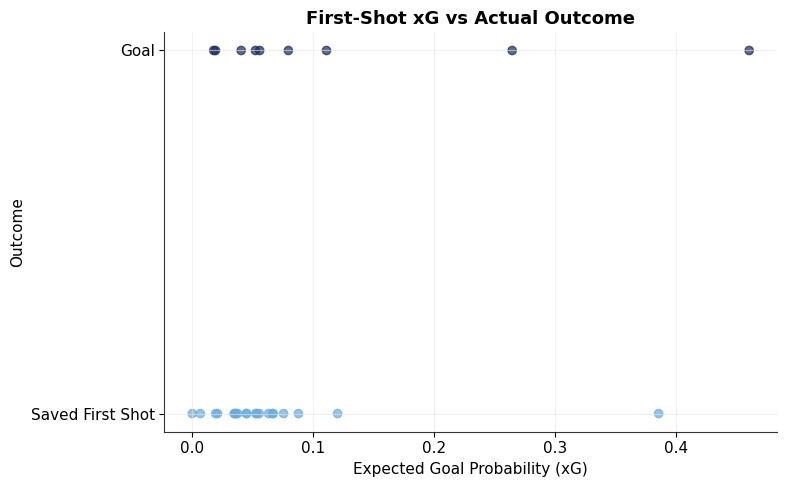

In [35]:
plt.figure(figsize=(8,5))

colors = first_shot_xg_df['first_shot_conceded'].map({
    0: CITY_BLUE,
    1: CITY_DARK
})

plt.scatter(
    first_shot_xg_df['xg'],
    first_shot_xg_df['first_shot_conceded'],
    c=colors,
    alpha=0.7
)

plt.yticks([0,1], ['Saved First Shot','Goal'])

plt.title(
    "First-Shot xG vs Actual Outcome",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Expected Goal Probability (xG)")
plt.ylabel("Outcome")

plt.tight_layout()
sns.despine()
plt.savefig(
    "../outputs/figures/first_shot_xg_vs_goal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Average xG of First Shots by Outcome

In [36]:
avg_xg_by_outcome = (
    first_shot_xg_df
    .groupby('first_shot_conceded')['xg']
    .mean()
)

avg_xg_by_outcome

first_shot_conceded
0    0.065382
1    0.122398
Name: xg, dtype: float64

In [37]:
avg_xg_df = avg_xg_by_outcome.reset_index()

avg_xg_df['Outcome'] = avg_xg_df['first_shot_conceded'].map({
    0: 'Saved First Shot',
    1: 'Goal'
})

avg_xg_df

,first_shot_conceded,xg,Outcome
0,0,0.065382,Saved First Shot
1,1,0.122398,Goal


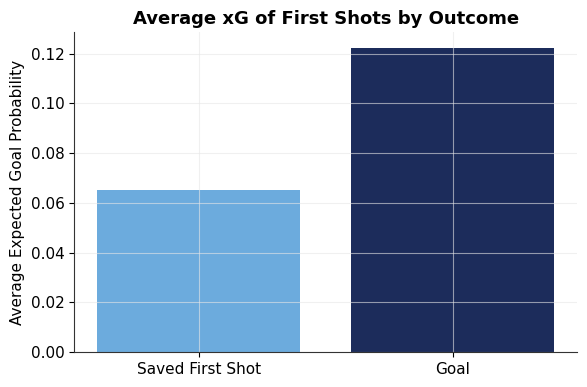

In [38]:
plt.figure(figsize=(6,4))

plt.bar(
    avg_xg_df['Outcome'],
    avg_xg_df['xg'],
    color=[CITY_BLUE, CITY_DARK]
)

plt.title(
    "Average xG of First Shots by Outcome",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Average Expected Goal Probability")

plt.tight_layout()
sns.despine()
plt.savefig(
    "../outputs/figures/average_xg_first_shots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Shot Quality and First-Shot Outcomes

The expected goals (xG) metric provides an estimate of the probability that a shot results in a goal based on factors such as shot location, angle, and defensive context. Incorporating xG allows us to evaluate not only whether a goal occurred, but also whether the chance itself was statistically dangerous.

The scatter plot comparing first-shot xG with the actual outcome shows that most first shots faced by Manchester City during the season were relatively low-probability chances, typically with xG values below 0.10. Goals that were conceded generally appear at higher xG values, indicating that when the first shot resulted in a goal it often came from a higher-quality opportunity.

However, there are also instances where low-xG shots resulted in goals. These cases highlight the inherent randomness present in football outcomes and demonstrate why probabilistic models such as xG are useful for distinguishing between expected and unexpected results.

To further quantify this relationship, the average xG values were compared for first shots that were saved versus those that resulted in goals. The results show that first-shot goals had a noticeably higher average xG than saved shots. This suggests that, in general, goals conceded on the first shot tended to originate from more dangerous chances.

Overall, this analysis indicates that while the timing of the first shot can carry significant leverage in matches where Manchester City faces relatively few shots, the **quality of the chance itself remains a key determinant of whether a goal occurs**. For this reason, xG is included as a feature in the predictive model used later in the analysis to estimate the probability that the first shot faced results in a goal.

## Feature Engineering for First-Shot Concession Model

In [39]:
time_to_first_shot = first_shots[['game_id', 'minute']].rename(
    columns={'minute': 'time_to_first_shot'}
)

time_to_first_shot.head()

,game_id,time_to_first_shot
0,7126,44
1,7138,34
2,7139,12
3,7149,14
4,7164,52


In [40]:
shots_faced_df = shots_faced_per_match.reset_index()
shots_faced_df.columns = ['game_id', 'shots_faced']

shots_faced_df.head()

,game_id,shots_faced
0,7126,2
1,7138,2
2,7139,2
3,7149,3
4,7164,1


In [41]:
opponent_df = first_shots[['game_id', 'team']].rename(
    columns={'team': 'opponent'}
)

opponent_df.head()

,game_id,opponent
0,7126,Brighton
1,7138,Everton
2,7139,Bournemouth
3,7149,Liverpool
4,7164,Watford


In [42]:
target_df = first_shots[['game_id', 'first_shot_conceded']]
target_df.head()

,game_id,first_shot_conceded
0,7126,0
1,7138,1
2,7139,1
3,7149,0
4,7164,0


In [43]:
first_shot_xg = first_shots[['game_id', 'xg']].rename(
    columns={'xg': 'first_shot_xg'}
)

first_shot_xg.head()

,game_id,first_shot_xg
0,7126,0.034634
1,7138,0.460745
2,7139,0.017740
3,7149,0.067057
4,7164,0.053284


## Machine Learning Model

In [44]:
model_df = (
    time_to_first_shot
    .merge(shots_faced_df, on='game_id')
    .merge(opponent_df, on='game_id')
    .merge(first_shot_xg, on='game_id')
    .merge(target_df, on='game_id')
)

model_df.head()

,game_id,time_to_first_shot,shots_faced,opponent,first_shot_xg,first_shot_conceded
0,7126,44,2,Brighton,0.034634,0
1,7138,34,2,Everton,0.460745,1
2,7139,12,2,Bournemouth,0.017740,1
3,7149,14,3,Liverpool,0.067057,0
4,7164,52,1,Watford,0.053284,0


In [45]:
model_df.shape
model_df.describe()

,game_id,time_to_first_shot,shots_faced,first_shot_xg,first_shot_conceded
count,29.000000,29.000000,29.000000,29.000000,29.000000
mean,7300.448276,31.586207,2.586207,0.083077,0.310345
std,111.586157,20.800957,1.500410,0.106469,0.470824
min,7126.000000,0.000000,1.000000,0.000000,0.000000
25%,7215.000000,12.000000,1.000000,0.035260,0.000000
50%,7298.000000,34.000000,2.000000,0.052632,0.000000
75%,7382.000000,45.000000,3.000000,0.075585,1.000000
max,7480.000000,88.000000,7.000000,0.460745,1.000000


In [46]:
model_df_encoded = pd.get_dummies(
    model_df,
    columns=['opponent'],
    drop_first=True
)

In [47]:
X = model_df_encoded.drop(columns=['game_id', 'first_shot_conceded'])
y = model_df_encoded['first_shot_conceded']

X.head()

,time_to_first_shot,shots_faced,first_shot_xg,opponent_Bournemouth,opponent_Brighton,opponent_Burnley,opponent_Chelsea,opponent_Everton,opponent_Huddersfield,opponent_Leicester,...,opponent_Manchester City,opponent_Manchester United,opponent_Newcastle United,opponent_Southampton,opponent_Stoke,opponent_Swansea,opponent_Tottenham,opponent_Watford,opponent_West Bromwich Albion,opponent_West Ham
0,44,2,0.034634,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,34,2,0.460745,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,12,2,0.017740,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,14,3,0.067057,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52,1,0.053284,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [50]:
y_pred = model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.625
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.00      0.00      0.00         2

    accuracy                           0.62         8
   macro avg       0.36      0.42      0.38         8
weighted avg       0.54      0.62      0.58         8



In [52]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values()

feature_importance

opponent_Watford                -0.499167
opponent_Swansea                -0.479706
opponent_Newcastle United       -0.344514
opponent_Huddersfield           -0.321144
opponent_West Ham               -0.317633
opponent_Manchester United      -0.304829
opponent_Burnley                -0.295937
opponent_Chelsea                -0.273622
opponent_Southampton            -0.268240
time_to_first_shot              -0.005323
opponent_Manchester City         0.000000
opponent_Brighton                0.000000
opponent_Leicester               0.000000
opponent_Liverpool               0.100974
shots_faced                      0.166301
first_shot_xg                    0.198015
opponent_Bournemouth             0.385018
opponent_Tottenham               0.397244
opponent_West Bromwich Albion    0.549690
opponent_Stoke                   0.648059
opponent_Everton                 1.023307
dtype: float64

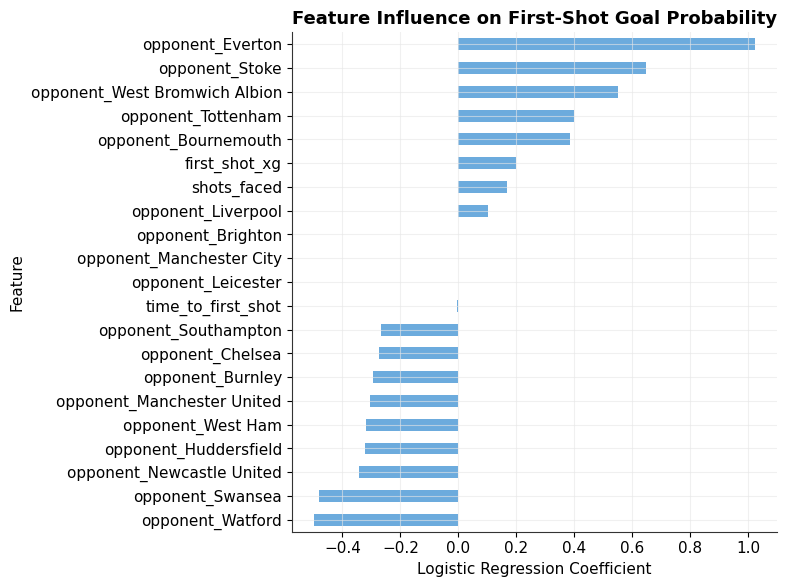

In [53]:
plt.figure(figsize=(8,6))

feature_importance.sort_values().plot(
    kind='barh',
    color=CITY_BLUE
)

plt.title(
    "Feature Influence on First-Shot Goal Probability",
    fontsize=13,
    weight='bold'
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
sns.despine()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Interpretation

A logistic regression model was trained to estimate the probability that the first shot on target faced in a match results in a goal.

Because the dataset is small (29 matches with at least one shot faced), the model serves primarily as a proof-of-concept baseline rather than a predictive production model.

The feature coefficients indicate how contextual match features influence the probability of conceding on the first shot. Positive coefficients increase the predicted probability of a goal, while negative coefficients decrease it.

Future work would expand the dataset to multiple seasons and additional goalkeepers to improve model stability and generalization.

## Multi-Season Dataset Construction

In [54]:
import pandas as pd
import glob
import os

In [55]:
data_path = "../data/raw"

files = glob.glob(os.path.join(data_path, "*_ederson_shots.csv"))

dfs = []

for file in files:

    df_temp = pd.read_csv(file)

    # Extract season name from filename
    season = os.path.basename(file).split("_")[0]
    df_temp["season"] = season

    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

df.head()

,league,season,game,team,player,league_id,season_id,game_id,date,shot_id,...,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result,ederson_minutes
0,ENG-Premier League,2017-18,2017-08-12 Brighton-Manchester City,Brighton,Davy Pröpper,1,2017,7126,2017-08-12 17:30:00,158178,...,NaN,NaN,0.015211,0.775,0.561,55,Right Foot,From Corner,Missed Shot,90
1,ENG-Premier League,2017-18,2017-08-12 Brighton-Manchester City,Brighton,Davy Pröpper,1,2017,7126,2017-08-12 17:30:00,158182,...,NaN,NaN,0.022634,0.755,0.408,56,Right Foot,From Corner,Missed Shot,90
2,ENG-Premier League,2017-18,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158173,...,175828.0,Pascal Groß,0.034634,0.907,0.557,44,NaN,Set Piece,Saved Shot,90
3,ENG-Premier League,2017-18,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158180,...,NaN,NaN,0.087967,0.885,0.472,55,Right Foot,From Corner,Saved Shot,90
4,ENG-Premier League,2017-18,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158181,...,NaN,NaN,0.095741,0.883,0.522,55,Left Foot,From Corner,Blocked Shot,90


In [56]:
shots_faced_mask = (
    (
        (df['team'] != 'Manchester City') &
        (df['result'].isin(['Saved Shot','Goal']))
    )
    |
    (
        (df['team'] == 'Manchester City') &
        (df['result'] == 'Own Goal')
    )
) & (
    df['minute'] <= df['ederson_minutes']
)
df_faced = df[shots_faced_mask]
df_faced.head()

,league,season,game,team,player,league_id,season_id,game_id,date,shot_id,...,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result,ederson_minutes
2,ENG-Premier League,2017-18,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158173,...,175828.0,Pascal Groß,0.034634,0.907,0.557,44,NaN,Set Piece,Saved Shot,90
3,ENG-Premier League,2017-18,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158180,...,NaN,NaN,0.087967,0.885,0.472,55,Right Foot,From Corner,Saved Shot,90
25,ENG-Premier League,2017-18,2017-08-21 Manchester City-Everton,Everton,Wayne Rooney,1,2017,7138,2017-08-21 20:00:00,158522,...,176228.0,Dominic Calvert-Lewin,0.460745,0.916,0.452,34,Left Foot,Open Play,Goal,90
27,ENG-Premier League,2017-18,2017-08-21 Manchester City-Everton,Everton,Wayne Rooney,1,2017,7138,2017-08-21 20:00:00,158536,...,176230.0,Gylfi Sigurdsson,0.009706,0.860,0.461,78,NaN,Set Piece,Saved Shot,90
49,ENG-Premier League,2017-18,2017-08-26 Bournemouth-Manchester City,Bournemouth,Charlie Daniels,1,2017,7139,2017-08-26 12:30:00,159184,...,NaN,NaN,0.017740,0.878,0.806,12,Left Foot,Open Play,Goal,90


In [57]:
shots_faced_per_match = (
    df_faced
    .groupby('game_id')
    .size()
)

shots_faced_per_match.describe()

count    245.000000
mean       2.628571
std        1.653610
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        8.000000
dtype: float64

In [58]:
df_faced_sorted = df_faced.sort_values(
    ['game_id','minute']
)

first_shots = df_faced_sorted.groupby('game_id').first().reset_index()
first_shots['first_shot_conceded'] = (
    first_shots['result'] == 'Goal'
).astype(int)
first_shots.shape

(245, 23)

In [59]:
time_to_first_shot = first_shots[['game_id', 'minute']].rename(
    columns={'minute': 'time_to_first_shot'}
)

shots_faced_df = shots_faced_per_match.reset_index()
shots_faced_df.columns = ['game_id', 'shots_faced']

opponent_df = first_shots[['game_id', 'team']].rename(
    columns={'team': 'opponent'}
)

target_df = first_shots[['game_id', 'first_shot_conceded']]

first_shot_xg = first_shots[['game_id', 'xg']].rename(
    columns={'xg': 'first_shot_xg'}
)



In [60]:
model_df = (
    time_to_first_shot
    .merge(shots_faced_df, on='game_id')
    .merge(opponent_df, on='game_id')
    .merge(first_shot_xg, on='game_id')
    .merge(target_df, on='game_id')
)
model_df

,game_id,time_to_first_shot,shots_faced,opponent,first_shot_xg,first_shot_conceded
0,7126,44,2,Brighton,0.034634,0
1,7138,34,2,Everton,0.460745,1
2,7139,12,2,Bournemouth,0.017740,1
3,7149,14,3,Liverpool,0.067057,0
4,7164,52,1,Watford,0.053284,0
...,...,...,...,...,...,...
240,26878,42,4,Nottingham Forest,0.022183,0
241,26909,39,2,Manchester United,0.033529,0
242,26917,7,2,Crystal Palace,0.368124,1
243,26970,3,1,Bournemouth,0.075844,0


In [61]:
season_df = first_shots[['game_id','season']]
model_df = model_df.merge(season_df,on='game_id')

model_df.shape

(245, 7)

In [62]:
model_df_encoded = pd.get_dummies(
    model_df,
    columns=['opponent', 'season'],
    drop_first=True
)
model_df_encoded.shape

(245, 42)

In [63]:
X = model_df_encoded.drop(columns=['game_id', 'first_shot_conceded'])
y = model_df_encoded['first_shot_conceded']

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [66]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.6774193548387096
              precision    recall  f1-score   support

           0       0.68      0.86      0.76        37
           1       0.67      0.40      0.50        25

    accuracy                           0.68        62
   macro avg       0.67      0.63      0.63        62
weighted avg       0.68      0.68      0.66        62



## First-Shot Concession Rate by Season

In [67]:
season_rates = (
    first_shots
    .groupby('season')['first_shot_conceded']
    .mean()
)

season_rates

season
2017-18    0.310345
2018-19    0.393939
2019-20    0.310345
2020-21    0.303030
2021-22    0.272727
2022-23    0.363636
2023-24    0.250000
2024-25    0.347826
Name: first_shot_conceded, dtype: float64

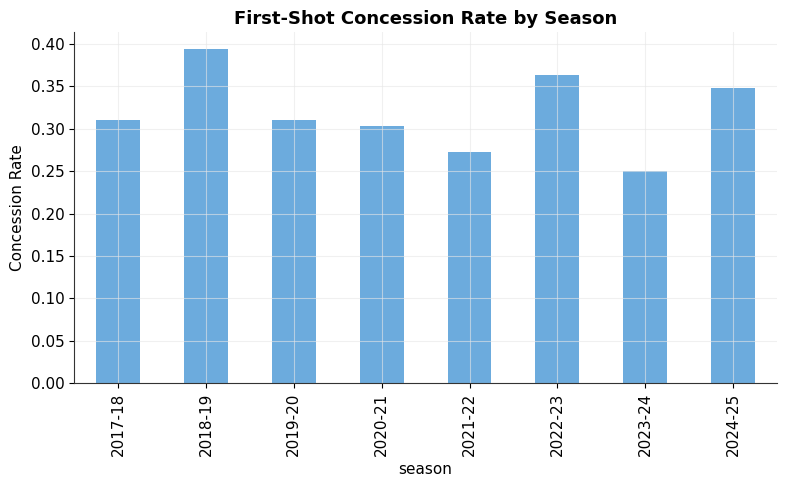

In [68]:
plt.figure(figsize=(8,5))

season_rates.plot(
    kind='bar',
    color=CITY_BLUE
)

plt.title(
    "First-Shot Concession Rate by Season",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Concession Rate")

plt.tight_layout()
sns.despine()
plt.savefig(
    "../outputs/figures/concession_rate_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: First-Shot Concession Rate by Season

The chart above shows the proportion of matches in each season where the **first shot on target faced by Ederson resulted in a goal**. This metric provides insight into how often Manchester City conceded immediately upon being tested, which is particularly relevant for a team that typically allows relatively few shots per match.

Across the eight seasons analyzed, the first-shot concession rate fluctuates between approximately **25% and 40%**. Most seasons cluster around the **30–35% range**, suggesting that roughly one in three matches where Manchester City faced an early shot on target resulted in an immediate concession.

Some variation between seasons is visible. For example, the **2018–19 season shows the highest first-shot concession rate**, approaching 40%, while the **2023–24 season appears to have the lowest rate**, closer to 25%. These differences may reflect a combination of factors such as defensive structure, opponent quality, shot quality, and natural statistical variation.

Overall, however, the results indicate that the likelihood of conceding on the first shot has remained **relatively consistent across seasons**, reinforcing the earlier finding that first-shot concessions are not purely random events but occur at a measurable and somewhat stable rate.

This seasonal perspective adds an important temporal dimension to the analysis and provides context for the predictive modeling stage. By incorporating multiple seasons of data, the machine learning model can learn patterns from a larger and more representative sample of matches, improving the reliability of estimates for the probability that the **first shot on target results in a goal**.

## Goalkeeper Performance: Expected vs Actual First-Shot Goals

In [69]:
# Expected goals from first shots
expected_goals = first_shots['xg'].sum()

# Actual goals conceded
actual_goals = first_shots['first_shot_conceded'].sum()

performance_diff = actual_goals - expected_goals

print("Expected Goals (First Shots):", round(expected_goals,2))
print("Actual Goals Conceded:", actual_goals)
print("Actual - Expected:", round(performance_diff,2))

Expected Goals (First Shots): 41.22
Actual Goals Conceded: 78
Actual - Expected: 36.78


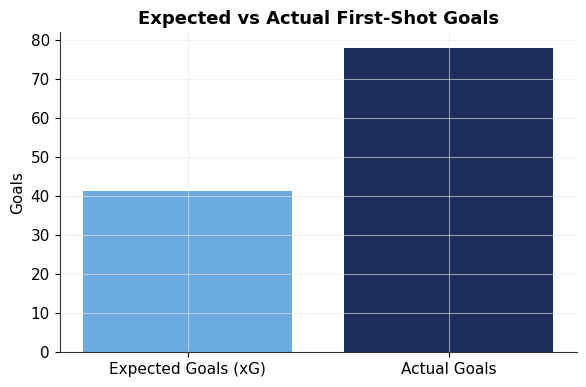

In [70]:
plt.figure(figsize=(6,4))

values = [expected_goals, actual_goals]

plt.bar(
    ["Expected Goals (xG)", "Actual Goals"],
    values,
    color=[CITY_BLUE, CITY_DARK]
)

plt.title(
    "Expected vs Actual First-Shot Goals",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Goals")
sns.despine()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/expected_vs_actual_first_shot_goals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Expected vs Actual First-Shot Goals

The chart above compares the **total expected goals (xG)** of the first shots faced by Manchester City with the **actual number of goals conceded** from those shots across all analyzed seasons.

The cumulative expected goals from the first shots faced is approximately **41 xG**, meaning that based on historical shot characteristics (location, angle, defensive pressure, etc.), we would expect around **41 goals** to be conceded from these chances.

However, the actual number of goals conceded from the first shot is **78 goals**, which is substantially higher than the expected value.

This difference suggests that, across the full dataset, **first-shot goals occurred more frequently than the underlying shot quality would predict**. In other words, the finishing efficiency of these first shots was significantly higher than the average expectation captured by the xG model.

Several factors may contribute to this discrepancy:

- The **first shot in a match may occur in particularly vulnerable defensive moments**, such as transitions or defensive lapses.
- Small sample sizes within individual matches may introduce **higher variability in outcomes**.
- Tactical or contextual elements not captured by the xG model (such as defensive positioning, goalkeeper readiness, or match state) may influence the likelihood of conceding on the first shot.

This comparison highlights the value of combining **probabilistic metrics (xG)** with **actual match outcomes**, as it provides additional context for interpreting goalkeeper performance and defensive vulnerability in early match situations.

## First-Shot Goalkeeper Performance by Season

In [71]:
season_perf = (
    first_shots
    .groupby("season")
    .agg(
        expected_goals=("xg","sum"),
        actual_goals=("first_shot_conceded","sum")
    )
)

season_perf["performance_diff"] = (
    season_perf["actual_goals"] - season_perf["expected_goals"]
)

season_perf

,expected_goals,actual_goals,performance_diff
season,,,
2017-18,2.409228,9,6.590772
2018-19,6.820181,13,6.179819
2019-20,4.469613,9,4.530387
2020-21,6.885475,10,3.114525
2021-22,5.050408,9,3.949592
2022-23,6.101645,12,5.898355
2023-24,4.540895,8,3.459105
2024-25,4.939985,8,3.060015


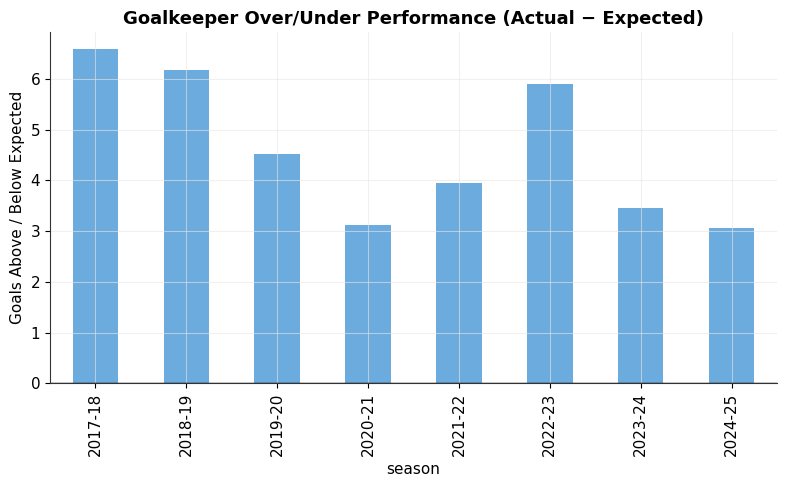

In [72]:
plt.figure(figsize=(8,5))

season_perf["performance_diff"].plot(
    kind="bar",
    color=CITY_BLUE
)

plt.axhline(0, color="black", linewidth=1)

plt.title(
    "Goalkeeper Over/Under Performance (Actual − Expected)",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Goals Above / Below Expected")
sns.despine()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/goalkeeper_over_under_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation: Goalkeeper Over/Under Performance by Season

The figure above illustrates the difference between **actual goals conceded** and **expected goals (xG)** from the first shot faced in each season. This metric, calculated as **Actual Goals − Expected Goals**, provides a way to evaluate how outcomes compare to statistical expectations based on shot quality.

Positive values indicate that **more goals were conceded than expected**, while negative values would indicate that fewer goals were conceded than predicted by the xG model.

Across all seasons shown in the chart, the values remain **consistently positive**, indicating that first shots resulted in goals more often than their underlying shot probabilities would suggest.

For example:

- In the **2017–18 season**, the difference between actual and expected goals is approximately **+6.6 goals**, indicating that first-shot goals occurred significantly more often than predicted by shot quality.
- The **2018–19 season** also shows a large positive difference of around **+6.2 goals**.
- Even in seasons with smaller gaps, such as **2020–21 and 2024–25**, the difference remains positive, suggesting that goals from first shots consistently exceeded their expected probability.

Overall, the results suggest that the **first shot in a match may carry a disproportionate scoring impact relative to its xG value**. This could indicate that early-match defensive situations tend to produce chances that are either more dangerous than typical shots with similar xG values or that contextual factors—such as defensive organization, match transitions, or goalkeeper readiness—play a role that is not fully captured by standard expected goals models.

This seasonal analysis reinforces the earlier finding that while shot quality remains an important predictor of goals, **the first shot faced in a match may represent a uniquely high-leverage event within the defensive structure of a team**.

## Key Findings

This analysis examined the dynamics of the **first shot on target faced by Manchester City during matches in which Ederson was the starting goalkeeper**, combining event-level shot data with expected goals (xG) metrics and machine learning techniques.

Several important patterns emerge from the analysis:

**1. First-shot concessions occur at a measurable and consistent rate**

Across eight seasons of data, the first shot on target resulted in a goal in roughly **25–40% of matches** where a shot was faced. Most seasons cluster around the **30–35% range**, indicating that early defensive moments carry significant leverage in matches where Manchester City faces relatively few shots.

**2. Shot quality strongly influences outcomes**

Analysis of expected goals shows that first-shot goals tend to occur from **higher-quality chances** than those that are saved. On average, the xG value of goals is noticeably higher than that of saved shots, confirming that chance quality remains a key determinant of scoring outcomes.

**3. First-shot outcomes often exceed statistical expectations**

When comparing expected goals to actual goals across all seasons, the total number of goals conceded (**78**) substantially exceeds the expected total (**~41 xG**). This suggests that first shots in matches are converted at a higher rate than typical shots with similar xG values.

**4. Seasonal variation exists but the pattern remains consistent**

Although concession rates fluctuate from season to season, every season analyzed shows **more goals conceded than expected based on shot quality**, indicating that the phenomenon persists across multiple tactical contexts and squad configurations.

**5. Predictive modeling benefits from contextual features**

By constructing a multi-season dataset incorporating features such as:

- time to first shot
- total shots faced
- opponent team
- shot quality (xG)
- season context

a logistic regression model can estimate the probability that the **first shot on target results in a goal**. While predictive performance remains limited by dataset size, the modeling pipeline demonstrates how contextual match features can be combined with probabilistic shot metrics to analyze concession risk.

Overall, the results suggest that while shot quality remains the strongest predictor of goals, **the first shot faced in a match represents a uniquely high-impact defensive moment**, where outcomes may exceed statistical expectations derived from typical shot models.

## Future Work

This analysis can be expanded in several directions:

- Extend the dataset to include additional goalkeepers for comparison
- Apply more advanced models such as gradient boosting or random forests
- Evaluate whether early-match defensive phases differ tactically